[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FM4CS/thor_terratorch_ext/blob/main/notebooks/thor_segmentation_sen1floods11.ipynb)

### Setup for Google Colab

If you are running this notebook in Google Colab, complete the following steps:

1. In Colab, we recommend going to **Runtime → Change runtime type** and selecting **T4 GPU**
2. Install the **TerraTorch THOR** extension and the required packages
3. Download the dataset (as part of the notebook)

In [24]:
import os

IN_COLAB = bool(os.getenv("COLAB_RELEASE_TAG"))
if IN_COLAB:
    %pip install git+https://github.com/fm4cs/thor_terratorch_ext.git

  Cloning https://github.com/fm4cs/thor_terratorch_ext.git to /tmp/pip-req-build-lmniin01
  Running command git clone --filter=blob:none --quiet https://github.com/fm4cs/thor_terratorch_ext.git /tmp/pip-req-build-lmniin01
  Resolved https://github.com/fm4cs/thor_terratorch_ext.git to commit b43d5b7c61c425997a3e8710f7f815c70f6e1d17
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/FM4CS/THOR (to revision v1.0.2) to /tmp/pip-install-fgigq2lg/thor_56d874ddad924060a3fa080556417b4a
  Running command git clone --filter=blob:none --quiet https://github.com/FM4CS/THOR /tmp/pip-install-fgigq2lg/thor_56d874ddad924060a3fa080556417b4a
  Resolved https://github.com/FM4CS/THOR to commit 68a5fac0b4c98764fa88e6fff1be2dc33f051636
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


------------

## Notebook: Segmentation Task in TerraTorch (Sen1Floods11)
> Adapted from the original notebook at: https://github.com/terrastackai/terratorch/blob/main/examples/segmentation/segmentation_sen1floods11.ipynb

This demo notebook shows how to use TerraTorch for a downstream semantic segmentation task using the Sen1Floods11 dataset.

Sen1Floods11 is a multimodal flood-mapping dataset that provides Sentinel-2 L1C optical imagery, Sentinel-1 GRD SAR data, and binary segmentation masks as labels. In this notebook, we focus exclusively on the Sentinel-2 L1C input modality. For examples that combine both Sentinel-1 and Sentinel-2 modalities, check out the multimodal examples folder.

### Data Exploration

We begin by downloading the dataset and performing a brief data exploration.

In [25]:
import gdown
from pathlib import Path


dataset_path = Path("../sen1floods11_v1.1")
archive_path = dataset_path.with_suffix(".tar.gz")

# Extract archive if dataset directory does not exist
if not dataset_path.exists():
    # Download archive if it does not exist
    if not archive_path.is_file():
        gdown.download(
            "https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS",
            str(archive_path),
            quiet=False,
        )
    !tar -xzf {archive_path} -C {dataset_path.parent}
!ls "{dataset_path}/data"

CopernicusDEM  JRCWaterHand  LabelHand	S1GRDHand  S1OtsuLabelHand  S2L1CHand


# Import the extension module to register the THOR FM model backbones

In [26]:
import thor_terratorch_ext  # noqa: F401

We instantiate the datamodule, the object we will use to load the files from disk to memory. For this task, we use the `GenericNonGeoSegmentationDataModule`, which is designed for standard segmentation workflows in TerraTorch.

In [27]:
import albumentations as A
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=8,
    num_workers=0,
    # We use the same roots for train/val/test and select samples via the given split files
    train_data_root=dataset_path / "data/S2L1CHand",
    train_label_data_root=dataset_path / "data/LabelHand",
    val_data_root=dataset_path / "data/S2L1CHand",
    val_label_data_root=dataset_path / "data/LabelHand",
    test_data_root=dataset_path / "data/S2L1CHand",
    test_label_data_root=dataset_path / "data/LabelHand",
    # Split files
    train_split=dataset_path / "splits/flood_train_data.txt",
    val_split=dataset_path / "splits/flood_valid_data.txt",
    test_split=dataset_path / "splits/flood_test_data.txt",
    # File patterns inside the roots above
    img_grep="*_S2Hand.tif",
    label_grep="*_LabelHand.tif",
    # RGB visualization uses channels [R,G,B] = [3,2,1]
    rgb_indices=[3, 2, 1],
    num_classes=2,
    # Sen1Floods11 S2 L1C dataset statistics (all 13 bands)
    means=[
        1626.916,
        1396.035,
        1364.061,
        1218.228,
        1466.073,
        2386.903,
        2845.613,
        2622.958,
        3077.482,
        486.874,
        63.779,
        2030.648,
        1179.166,
    ],
    stds=[
        700.171,
        739.095,
        735.248,
        864.937,
        776.880,
        921.368,
        1084.373,
        1022.634,
        1196.443,
        336.611,
        144.000,
        980.871,
        764.608,
    ],
)

# Call setup here so we can access dataset objects (e.g., datamodule.train_dataset) before training
datamodule.setup("fit")

In [28]:
val_dataset = datamodule.val_dataset

print(f"Available samples in the training dataset: {len(val_dataset)}")
print(f"Input shape of first sample: {val_dataset[0]['image'].shape}")

Available samples in the training dataset: 89
Input shape of first sample: torch.Size([13, 512, 512])


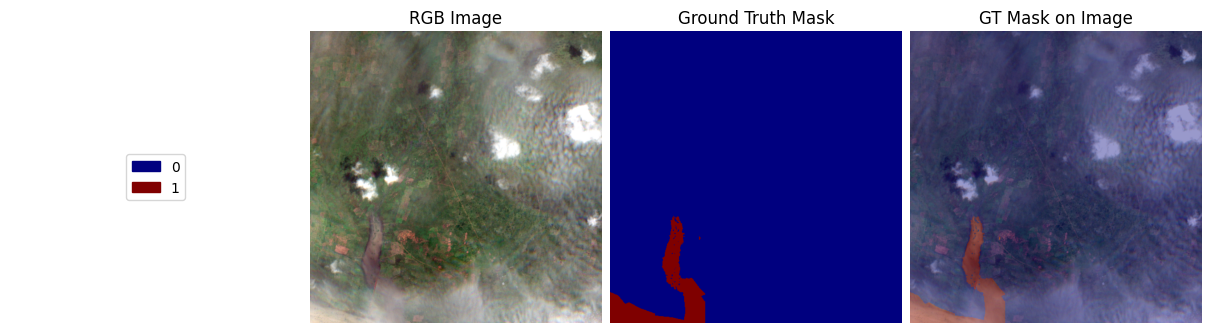

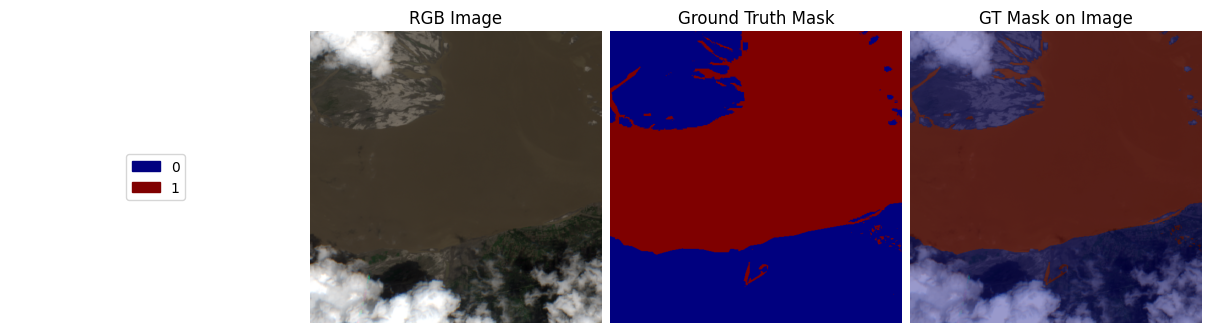

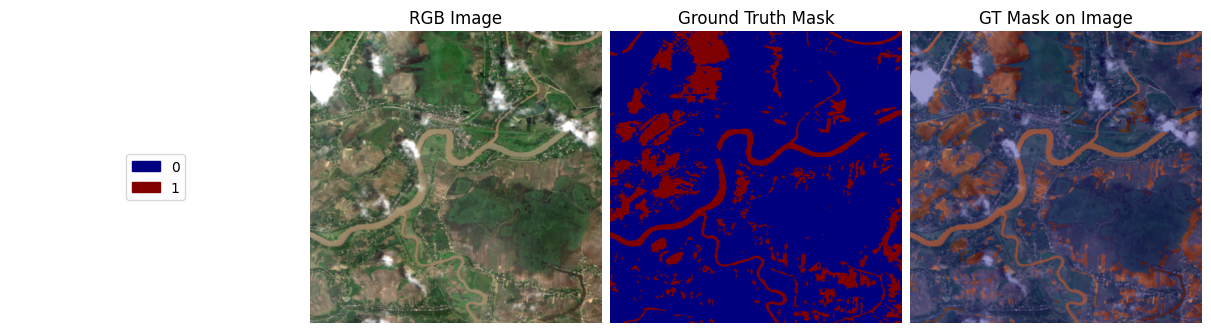

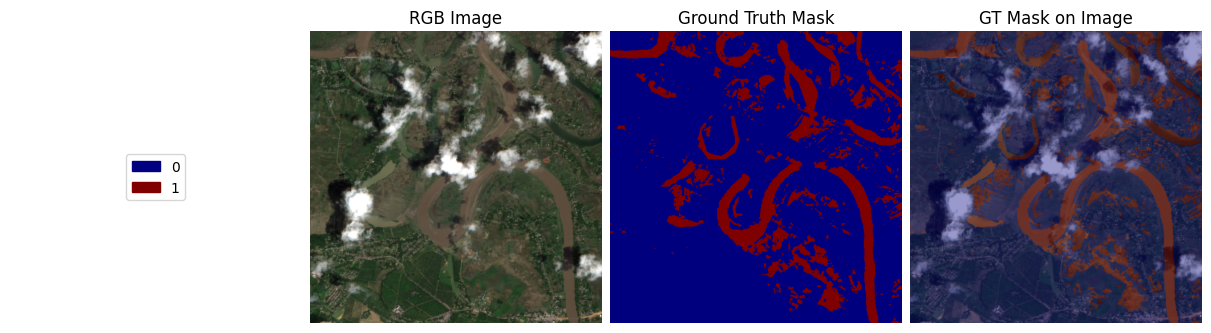

In [29]:
for i in range(10, 14):
    _ = val_dataset.plot(val_dataset[i])

### The model backbone factory

Before building the full end-to-end training pipeline, we first inspect the available encoders via the backbone registry and demonstrate how to manually instantiate a backbone. Since we want to use a THOR model, we filter the registry to show only the available THOR v1 backbones.

In [30]:
from terratorch.registry import BACKBONE_REGISTRY

thor_backbones = [name for name in BACKBONE_REGISTRY if "thor_v1" in name]

print(f"Available TerraTorch THOR backbones ({len(thor_backbones)}):")
for name in thor_backbones:
    print(name)

Available TerraTorch THOR backbones (4):
terratorch_thor_v1_tiny
terratorch_thor_v1_small
terratorch_thor_v1_base
terratorch_thor_v1_large


In [ ]:
# Initialise one of the models
model = BACKBONE_REGISTRY.build(
    "thor_v1_tiny",
    pretrained=True,
    model_bands=["BLUE", "GREEN", "RED", "NIR_BROAD"],
    input_params=dict(ground_covers=[2240], flexivit_patch_size_seqs=[8]),
)
print(model)

/usr/local/lib/python3.12/dist-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param ground_covers for model encoder with [2240]
  return self._registry[name](*constructor_args, **constructor_kwargs)
/usr/local/lib/python3.12/dist-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param flexivit_patch_size_seqs for model encoder with [8]
  return self._registry[name](*constructor_args, **constructor_kwargs)


THOREncoderWrapper(
  (model): ThorViTEncoder(
    (ind_patch_embed): IndFlexiPatchEmbed(
      (patch_embed): ModuleDict(
        (S2:Red): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:Green): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:Blue): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:NIR): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:RE1): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:RE2): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:RE3): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:RE4): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:SWIR1): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:SWIR2): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:CoastAerosal): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16))
        (S2:WaterVapor): Conv2d(1, 192, kernel_size=(16, 16), stride=

`model_bands` shows which bands the currently initialized model expects as input. THOR is pretrained on a broad set of spectral bands spanning multiple sensors, so you can select any subset relevant to your task.

In [32]:
print("Band configuration summary:")
print(f"  Using input bands   : {model.bands}")

Band configuration summary:
  Using input bands   : ['S2:Blue', 'S2:Green', 'S2:Red', 'S2:RE4']


Next, we show the output shapes of the encoder using a dummy input. The model returns a list containing the outputs of each encoder layer, which may differ depending on the specific encoder architecture.

In [33]:
import torch

# Dummy input to probe the model's feature outputs
dummy_input = torch.zeros(1, 4, 224, 224)  # (batch, channels, height, width)

with torch.no_grad():
    features = model(dummy_input)


print("Extracted features:")
for i, feat in enumerate(features):
    print(f"  Output layer {i + 1}: shape = {tuple(feat.shape)}")

Extracted features:
  Output layer 1: shape = (1, 980, 192)
  Output layer 2: shape = (1, 980, 192)
  Output layer 3: shape = (1, 980, 192)
  Output layer 4: shape = (1, 980, 192)
  Output layer 5: shape = (1, 980, 192)
  Output layer 6: shape = (1, 980, 192)
  Output layer 7: shape = (1, 980, 192)
  Output layer 8: shape = (1, 980, 192)
  Output layer 9: shape = (1, 980, 192)
  Output layer 10: shape = (1, 980, 192)
  Output layer 11: shape = (1, 980, 192)
  Output layer 12: shape = (1, 980, 192)


#### Band choice

In some cases, you may want to use a different set of input bands than those used during pretraining. This may be a different ordering, a subset, a superset, or a completely different set.

To do this, you can explicitly specify the bands to train on via the `model_bands` parameter.

In the patch embed layer, the weights corresponding to bands that exist in the pretrained model will be mapped to the correct order. Bands that do not exist will be randomly initialized.

In [34]:
# Build a THOR ViT backbone with a custom band configuration
model = BACKBONE_REGISTRY.build(
    "thor_v1_tiny",
    pretrained=True,
    model_bands=["GREEN", "RED", "BLUE"],  # Select RGB bands in G-R-B order
    input_params=dict(ground_covers=[2240], flexivit_patch_size_seqs=[8]),
)

In [35]:
print("Band configuration summary:")
print(f"  Using input bands   : {model.bands}")

Band configuration summary:
  Using input bands   : ['S2:Green', 'S2:Red', 'S2:Blue']


In [36]:
# The model now expects 3 input channels (G, R, B)
trial_data = torch.zeros(1, 3, 224, 224)  # (batch, channels, height, width)

with torch.no_grad():
    features = model(trial_data)

print("Extracted features:")
for i, feature in enumerate(features):
    print(f"  Output layer {i + 1}: shape = {tuple(feature.shape)}")

Extracted features:
  Output layer 1: shape = (1, 784, 192)
  Output layer 2: shape = (1, 784, 192)
  Output layer 3: shape = (1, 784, 192)
  Output layer 4: shape = (1, 784, 192)
  Output layer 5: shape = (1, 784, 192)
  Output layer 6: shape = (1, 784, 192)
  Output layer 7: shape = (1, 784, 192)
  Output layer 8: shape = (1, 784, 192)
  Output layer 9: shape = (1, 784, 192)
  Output layer 10: shape = (1, 784, 192)
  Output layer 11: shape = (1, 784, 192)
  Output layer 12: shape = (1, 784, 192)


### EncoderDecoder model factory

Model factories allow us to create full models for specific tasks, including decoders and task-specific heads. They return standard `torch.nn.Module` objects that you can use anywhere in your code. We create a semantic segmentation model with 4 output classes.

In [37]:
from terratorch.models import EncoderDecoderFactory

model_factory = EncoderDecoderFactory()

# Build a segmentation model:
# - backbone_* args configure the encoder backbone
# - decoder_* args configure the decoder
# - head_* args configure the task head

model = model_factory.build_model(
    task="segmentation",
    backbone="thor_v1_tiny",
    backbone_pretrained=True,
    backbone_model_bands=[
        "BLUE",
        "GREEN",
        "RED",
        "NIR_NARROW",
        "SWIR_1",
        "SWIR_2",
    ],
    backbone_input_params=dict(ground_covers=[2240], flexivit_patch_size_seqs=[8]),
    backbone_merge_method="mean",
    decoder="FCNDecoder",
    decoder_channels=128,
    num_classes=4,
    head_dropout=0.2,
)

The forward pass returns a `ModelOutput` object, which contains the main `output` as well as the outputs of any `auxiliary_heads`.

In [38]:
# Run a forward pass with a dummy input (6 bands, 224x224 matching ground_cover=2240 at 10m GSD)
dummy_input = torch.zeros(1, 6, 224, 224)  # (batch, channels, height, width)

with torch.no_grad():
    out = model(dummy_input)

print(f"Output shape: {out.output.shape}")

Output shape: torch.Size([1, 4, 224, 224])


### Building the TerraTorch training pipeline

Next, we build the TerraTorch training pipeline for the Sen1Flood11 segmentation task by configuring the model, loss, optimizer, and training hyperparameters.

At the highest level of abstraction, TerraTorch provides task-specific trainers. They build on the model factory introduced above and can be configured with any supported backbone, decoder, and head.

In [39]:
from terratorch.tasks import SemanticSegmentationTask

# Model configuration passed to the EncoderDecoderFactory
model_args = {
    "backbone": "thor_v1_tiny",
    "decoder": "FCNDecoder",  # use a FCN decoder
    "num_classes": 2,  # binary segmentation
    "backbone_pretrained": True,
    "backbone_merge_method": "mean",
    "backbone_model_bands": [
        "BLUE",
        "GREEN",
        "RED",
        "NIR_NARROW",
        "SWIR_1",
        "SWIR_2",
    ],
    "backbone_input_params": {
        "ground_covers": [2240],
        "flexivit_patch_size_seqs": [8],
    },
    "backbone_out_indices": [-1],
    "decoder_channels": 64,
    "head_dropout": 0.2,
}

task = SemanticSegmentationTask(
    model_args=model_args,
    model_factory="EncoderDecoderFactory",
    loss="ce",
    lr=2e-5,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    tiled_inference_on_validation=True,
    tiled_inference_on_testing=True,
    tiled_inference_parameters={
        "h_crop": 224,
        "h_stride": 128,
        "w_crop": 224,
        "w_stride": 128,
        "average_patches": True,
        "batch_size": 4,
    },
)

We initialize a new datamodule with extended arguments. This filters the 13 input bands to the six bands expected by the model, applies data normalization using the Sen1Floods11 dataset statistics, and adds training data transforms.

In [40]:
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=4,
    num_workers=0,
    train_data_root=dataset_path / "data/S2L1CHand",
    train_label_data_root=dataset_path / "data/LabelHand",
    val_data_root=dataset_path / "data/S2L1CHand",
    val_label_data_root=dataset_path / "data/LabelHand",
    test_data_root=dataset_path / "data/S2L1CHand",
    test_label_data_root=dataset_path / "data/LabelHand",
    train_split=dataset_path / "splits/flood_train_data.txt",
    val_split=dataset_path / "splits/flood_valid_data.txt",
    test_split=dataset_path / "splits/flood_test_data.txt",
    img_grep="*_S2Hand.tif",
    label_grep="*_LabelHand.tif",
    # Data transforms — crop to 224x224 to match ground_covers=[2240] at 10m GSD
    train_transform=[
        A.RandomCrop(height=224, width=224),
        A.D4(),  # random flips and rotations to stabilize training
        A.pytorch.ToTensorV2(),
    ],
    val_transform=[
        A.CenterCrop(height=224, width=224),
        A.pytorch.ToTensorV2(),
    ],
    test_transform=[
        A.CenterCrop(height=224, width=224),
        A.pytorch.ToTensorV2(),
    ],
    # Band selection: input data is 13-channel Sentinel-2 L1C.
    # We select a 6-band subset compatible with THOR.
    dataset_bands=[
        "COASTAL_AEROSOL",  # B01
        "BLUE",  # B02
        "GREEN",  # B03
        "RED",  # B04
        "RED_EDGE_1",  # B05
        "RED_EDGE_2",  # B06
        "RED_EDGE_3",  # B07
        "NIR_BROAD",  # B08
        "NIR_NARROW",  # B8A
        "WATER_VAPOR",  # B09
        "CIRRUS",  # B10
        "SWIR_1",  # B11
        "SWIR_2",  # B12
    ],
    output_bands=[
        "BLUE",
        "GREEN",
        "RED",
        "NIR_NARROW",
        "SWIR_1",
        "SWIR_2",
    ],
    # RGB visualization uses channels [R,G,B] = [2,1,0] (within output_bands above)
    rgb_indices=[2, 1, 0],
    # Sen1Floods11 dataset statistics for the selected output bands
    means=[1396.0, 1364.1, 1218.2, 3077.5, 2030.6, 1179.2],
    stds=[739.1, 735.2, 864.9, 1196.4, 980.9, 764.6],
    num_classes=2,
    no_data_replace=0,
    no_label_replace=-1,
)

The Lightning `Trainer` manages the full training loop for us (training/validation steps, device placement, logging, and checkpointing).

Below is a minimal example that trains for a small number of epochs and saves the best checkpoint.

In [41]:
import os
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import (
    LearningRateMonitor,
    ModelCheckpoint,
    RichProgressBar,
)
from lightning.pytorch.loggers import TensorBoardLogger

experiment = "tutorial"

os.makedirs("tutorial_experiments", exist_ok=True)
default_root_dir = os.path.join("tutorial_experiments", experiment)

logger = TensorBoardLogger(save_dir=default_root_dir, name=experiment)

checkpoint_callback = ModelCheckpoint(
    save_top_k=1,
    save_last=True,
)

trainer = Trainer(
    accelerator="auto",  # or specify cpu or gpu
    max_epochs=1,  # for demo purposes
    default_root_dir=default_root_dir,
    logger=logger,
    callbacks=[
        RichProgressBar(),
        checkpoint_callback,
        LearningRateMonitor(logging_interval="epoch"),
    ],
    log_every_n_steps=1,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [42]:
# Run training
trainer.fit(model=task, datamodule=datamodule)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  7.9 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.9 M                                                                                            
Non-trainable params: 320                                                                                          
Total params: 7.9 M                                                                                                
Total estimated model params size (MB): 31                                                                         
Modules in train mode: 376                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


In [43]:
# Run test loop
trainer.test(model=task, datamodule=datamodule)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │            0.5            │
│    test/Boundary_mIoU     │            0.0            │
│   test/Class_Accuracy_0   │            1.0            │
│   test/Class_Accuracy_1   │            0.0            │
│       test/F1_Score       │    0.46424591541290283    │
│        test/IoU_0         │    0.8665279746055603     │
│        test/IoU_1         │            0.0            │
│    test/Pixel_Accuracy    │    0.8665279746055603     │
│         test/loss         │    0.34778913855552673    │
│         test/mIoU         │    0.43326398730278015    │
│      test/mIoU_Micro      │     0.764490008354187     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.34778913855552673,
  'test/Accuracy': 0.5,
  'test/Boundary_mIoU': 0.0,
  'test/Class_Accuracy_0': 1.0,
  'test/Class_Accuracy_1': 0.0,
  'test/F1_Score': 0.46424591541290283,
  'test/IoU_0': 0.8665279746055603,
  'test/IoU_1': 0.0,
  'test/Pixel_Accuracy': 0.8665279746055603,
  'test/mIoU': 0.43326398730278015,
  'test/mIoU_Micro': 0.764490008354187}]

### Inference

In [44]:
# Check the size of the test dataset
datamodule.setup("test")
test_dataset = datamodule.test_dataset

print(f"Available samples in the test dataset: {len(test_dataset)}")

Available samples in the test dataset: 90


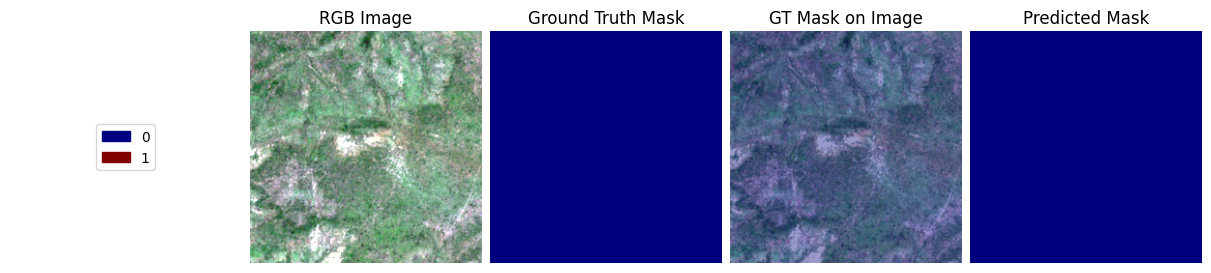

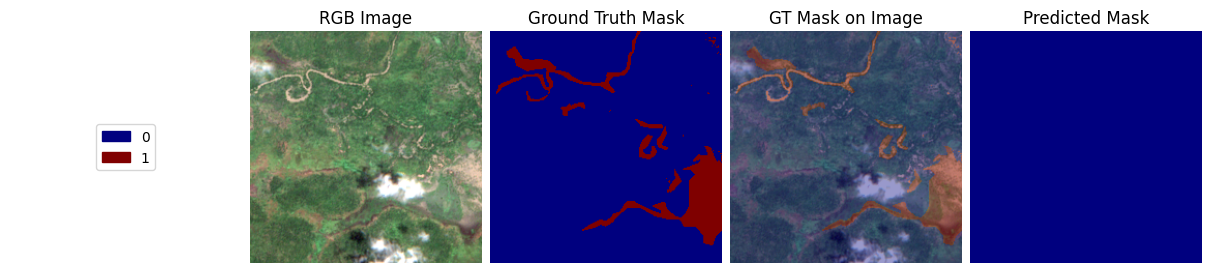

In [45]:
# Use the trained task for inference and visualization
task.eval()

# Get a batch from the test dataloader
datamodule.setup("test")
test_loader = datamodule.test_dataloader()

with torch.no_grad():
    batch = next(iter(test_loader))
    # Apply the same normalization used during training
    batch = datamodule.aug(batch)
    images = batch["image"].to(task.device)
    masks = batch["mask"].cpu().numpy()

    outputs = task(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

# Visualize a few predictions
num_examples = min(6, len(preds))
for i in range(2, num_examples):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)

## Training via CLI

Above, we introduced the required TerraTorch components and how to combine them flexibly. The same workflow can be run in a no-code setup by configuring all components in a YAML file and executing it via the PyTorch Lightning CLI.

We provide sample YAML configs for various THOR setups (S1, S2, and multimodal) that can serve as a starting point for similar pipelines.

**Note:** You may want to restart the session to free up memory before running the CLI workflow.

In [46]:
# !cd .. && terratorch fit -c config/sen1floods11_thor_S2.yaml